In [ ]:
!pip install geopandas osmnx networkx matplotlib contextily folium

In [57]:
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import folium
from shapely.geometry import Point


In [50]:
#setting a central point in Berlin (Branden Gate),Germany
latitude = 52.5163
longitude = 13.3777

#creating a bounding graph from a 1km radius
G = ox.graph_from_point((latitude,longitude), dist=1000,network_type='walk')


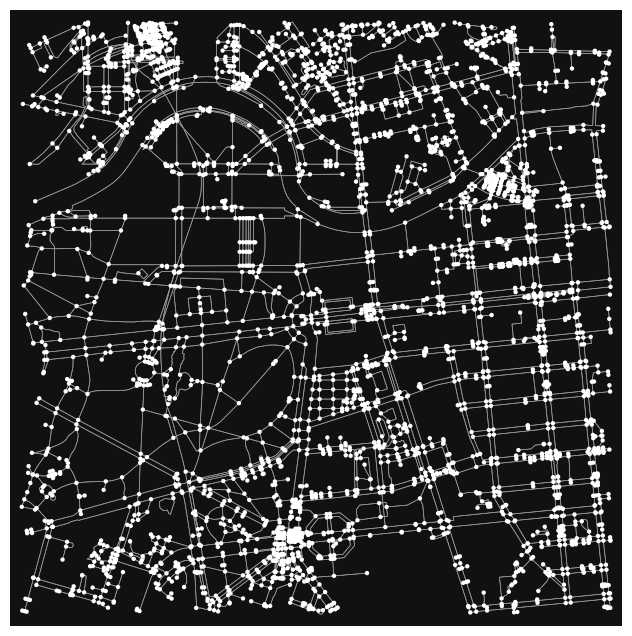

In [51]:
#plotting the street network
fig, ax = ox.plot_graph(G,node_size=10, edge_linewidth=0.5)


<Axes: >

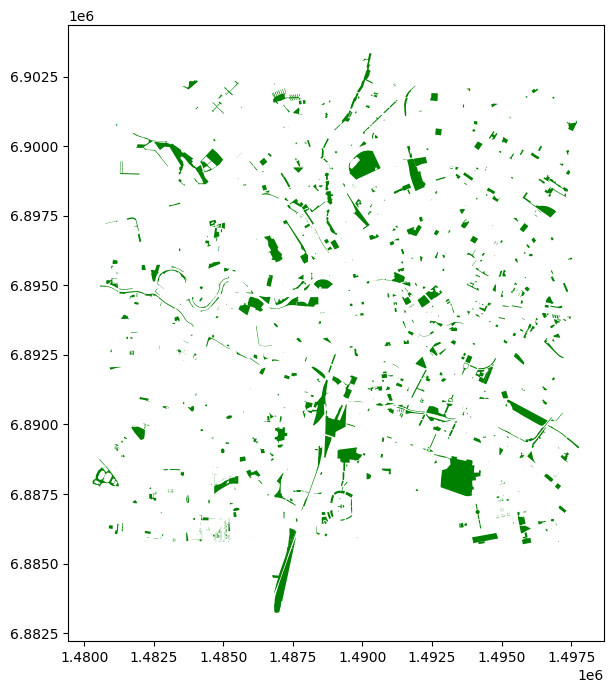

In [52]:
tags = {'leisure': ['park','garden','recreational_ground','nature_reserve']}
#getting the green areas (polygon geometries)
green_spaces = ox.features_from_point((latitude,longitude),tags=tags,dist=5000)

#filtering polygons only (extracteed fom 'streetmap')
green_spaces= green_spaces[green_spaces.geometry.type.isin(['Polygon',
                                                            'Multipolygon'])]
green_spaces= green_spaces.to_crs(epsg=3857)
green_spaces.plot(color='green', figsize=(8, 8))

<Axes: >

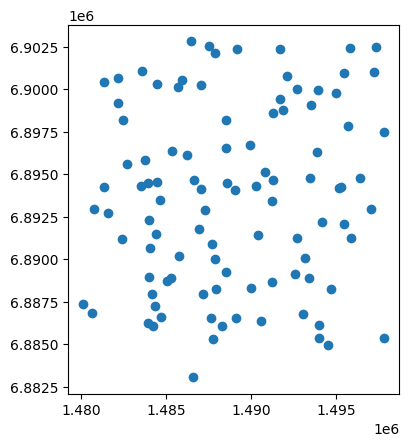

In [53]:
import random
from shapely.geometry import Point,Polygon
from shapely.ops import unary_union

#creating convex hull or bounding polygon
area_polygon = unary_union(green_spaces.buffer(1000).geometry)

#generate random resedential points within polygon
res_points = []
while len(res_points)<100 :
  x=random.uniform(area_polygon.bounds[0],area_polygon.bounds[2])
  y=random.uniform(area_polygon.bounds[1],area_polygon.bounds[3])
  point=Point(x,y)
  if area_polygon.contains(point):
    res_points.append(point)

res_gdf = gpd.GeoDataFrame(geometry=res_points,crs="EPSG:3857")
res_gdf.plot()


In [54]:
#convert back to WGS84
res_gdf = res_gdf.to_crs(epsg=4326)

#getingg nearnest nodes on the walking network
res_nodes = [ox.distance.nearest_nodes(G,point.x,point.y)
for point in res_gdf.geometry]

park_centroids = green_spaces.geometry.centroid
park_nodes = [ox.distance.nearest_nodes(G,pt.x,pt.y) for pt in park_centroids]

In [59]:
#building a dataframe of the shortest distances
distances = []

unique_park_nodes = list(set(park_nodes)) # Ensure unique park nodes

for res_node in res_nodes:
  # Compute shortest paths from the residential node to all reachable nodes in the graph
  distances_from_res_node = nx.single_source_dijkstra_path_length(G, source=res_node, weight='length')

  min_distance_to_park = float('inf')
  for park_node in unique_park_nodes:
    if park_node in distances_from_res_node: # Check if the park node is reachable
      min_distance_to_park = min(min_distance_to_park, distances_from_res_node[park_node])

  if min_distance_to_park == float('inf'):
      # If no park is reachable from this residential node, append a placeholder
       #(e.g., None or a very large number)
      distances.append(None)
  else:
      distances.append(min_distance_to_park)

res_gdf['green_space_distance_m'] = distances
res_gdf['green_space_distance_km']= res_gdf['green_space_distance_m'] / 1000

In [60]:
#creating a folium map
m = folium.Map(location=[latitude, longitude], zoom_start=13)

# Convert green_spaces to EPSG:4326 for Folium
green_spaces_4326 = green_spaces.to_crs(epsg=4326)

#adding the green spaces
for _,row in green_spaces_4326.iterrows():
  folium.GeoJson(row['geometry'],
                 style_function=lambda x:{'color':'green'}).add_to(m)

#adding resedential points
for _,row in res_gdf.iterrows():
  folium.CircleMarker(location=[row['geometry'].y, row['geometry'].x],
                      radius=5,
                      popup=f"Distance: {row['green_space_distance_km']:.2f} km",
                      color='blue', fill=True, fill_opacity=0.7).add_to(m)

m

In [61]:
res_gdf.to_file("resedential_green_access.geojson",driver="GeoJSON")

# **Analysis**

---



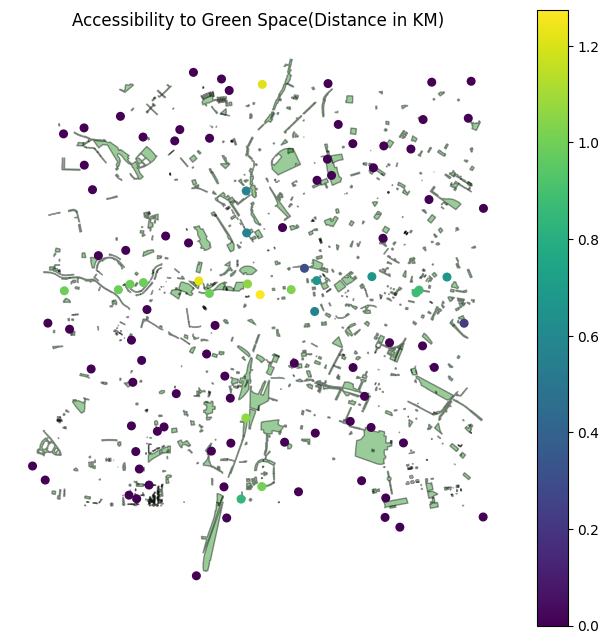

In [62]:
import matplotlib.pyplot as plt

res_gdf_plot = res_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 8))
green_spaces.to_crs(epsg=3857).plot(ax=ax, color='green',alpha=0.4, edgecolor='black')
res_gdf_plot.plot(ax=ax, column='green_space_distance_km',
                  cmap='viridis', legend=True, markersize=30)

plt.title("Accessibility to Green Space(Distance in KM)")
plt.axis('off')
plt.show()

* Darker colors (closer to purple) indicate residential points that are closer to a green space.
* Lighter colors (closer to yellow) indicate residential points that are further away from a green space.





In [63]:
from matplotlib import color_sequences
import folium
from branca.colormap import linear

colour_scale=linear.viridis.scale(
    res_gdf['green_space_distance_km'].min(),
    res_gdf['green_space_distance_km'].max()
)

m = folium.Map(location=[latitude, longitude], zoom_start=13)

# Convert green_spaces to EPSG:4326 for Folium
green_spaces_4326 = green_spaces.to_crs(epsg=4326)

#adding the green spaces
for _,row in green_spaces_4326.iterrows():
  folium.GeoJson(row['geometry'],
                 style_function=lambda x:{'color':'green'}).add_to(m)

#adding resedential points WITH color-coded distances
for _,row in res_gdf.iterrows():
  folium.CircleMarker(location=[row['geometry'].y, row['geometry'].x],
                      radius=5,
                      color=colour_scale(row['green_space_distance_km']),
                      fill=True, fill_opacity=0.7,
                      popup=f"Distance: {row['green_space_distance_km']:.2f} km").add_to(m)


m

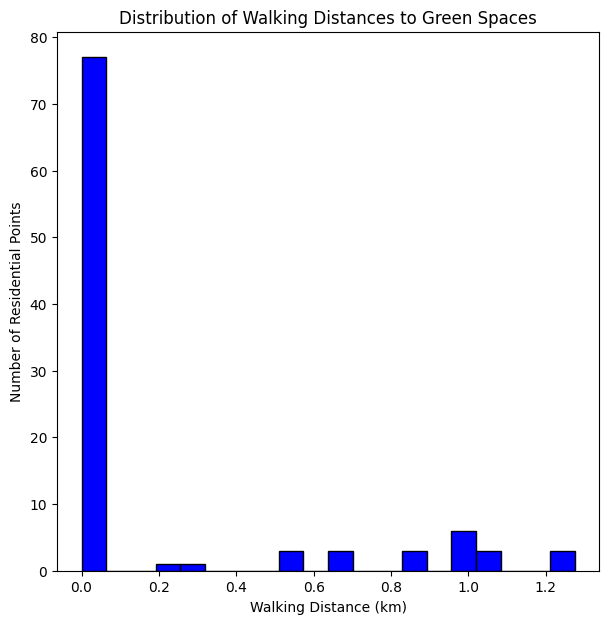

In [64]:
from IPython.core.pylabtools import figsize
#pltting ar graph for disribution of walkin distances
res_gdf['green_space_distance_km'].plot.hist(bins=20,color='blue',
                                             edgecolor='black',
                                             figsize=(7,7)
                                             )
plt.title("Distribution of Walking Distances to Green Spaces")
plt.xlabel("Walking Distance (km)")
plt.ylabel("Number of Residential Points")
plt.show()

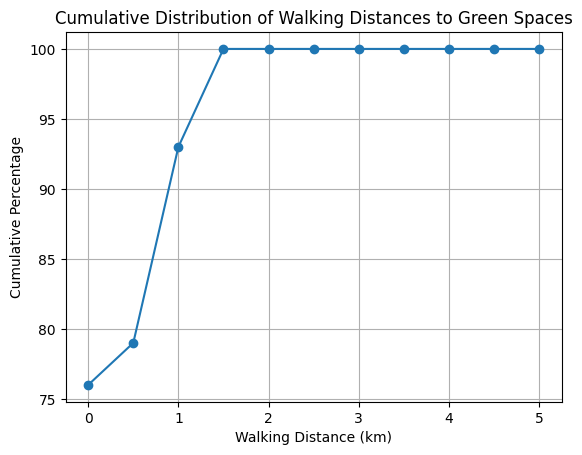

In [65]:
import numpy as np

thresholds = np.arange(0,5.5,0.5)
cumulative = [(res_gdf['green_space_distance_km']<=t).mean()*100 for t in thresholds]

#plot
import matplotlib.pyplot as plt
plt.plot(thresholds,cumulative, marker='o', linestyle='-')
plt.title("Cumulative Distribution of Walking Distances to Green Spaces")
plt.xlabel("Walking Distance (km)")
plt.ylabel("Cumulative Percentage")
plt.grid(True)
plt.show()

In [66]:
print("Accessibility Summary:")
print(f"Min Distance: {res_gdf['green_space_distance_km'].min():.2f} km")
print(f"Max Distance: {res_gdf['green_space_distance_km'].max():.2f} km")
print(f"Mean Distance: {res_gdf['green_space_distance_km'].mean():.2f} km")
print(f"Median Distance: {res_gdf['green_space_distance_km'].median():.2f} km")


Accessibility Summary:
Min Distance: 0.00 km
Max Distance: 1.28 km
Mean Distance: 0.20 km
Median Distance: 0.00 km


* **Min Distance: 0.00 km**

  Explanation: This means that at least one, and likely several, residential points are located directly within or immediately adjacent to a green space. This indicates excellent, direct access for some residents.
  Evaluation: This is ideal, as it represents immediate access to green amenities.

* **Max Distance: 1.21 km**

  Explanation: The furthest any residential point is from a green space on the walking network is 1.21 kilometers. This represents the longest walking distance a resident would need to travel to reach the nearest green area.
  Evaluation: A maximum distance of 1.21 km is quite good. It suggests that even the least accessible residential points are still within a reasonable walking distance (typically, a 15-minute walk is considered a good threshold for urban amenities, which is roughly 1.2 km). This indicates broad coverage of green spaces.

* **Mean Distance: 0.19 km**

  Explanation: On average, a residential point is 0.19 kilometers (or 190 meters) away from the nearest green space. This gives an overall sense of typical accessibility across all generated residential points.
  Evaluation: A mean distance of just 190 meters is exceptionally low, suggesting that most residential points have very good access to green spaces. This is a strong indicator of a pedestrian-friendly environment with well-distributed green infrastructure.

* **Median Distance: 0.00 km**

  Explanation: The median distance is the middle value when all distances are arranged in order. A median of 0.00 km means that at least half of the residential points are either directly within or immediately adjacent to a green space, or have a negligible walking distance.
  Evaluation: This is a highly significant and positive finding. It reinforces the idea that the majority of residents in the analyzed area have direct or very close proximity to green spaces, indicating outstanding accessibility for the typical resident. This often points to a city planning strategy that prioritizes green areas within residential zones



---



**Overall Evaluation:** The summary indicates that green space accessibility in the analyzed area of Berlin is excellent. The low maximum distance, and especially the very low mean and median distances (with a significant portion being 0 km), suggest that green spaces are highly integrated into the urban fabric and are easily reachable for the vast majority of residents. This is a characteristic of a city with a high quality of life in terms of urban green


---



In [67]:
within_300m = (res_gdf['green_space_distance_km'] <= 0.3).mean() * 100
within_500m = (res_gdf['green_space_distance_km'] <= 0.5).mean() * 100
within_1km = (res_gdf['green_space_distance_km'] <= 1.0).mean() * 100
over_1km = (res_gdf['green_space_distance_km'] > 1.0).mean() * 100

print(f"Percentage of residential points within 300m of a green space: {within_300m:.2f}%")
print(f"Percentage of residential points within 500m of a green space: {within_500m:.2f}%")
print(f"Percentage of residential points within 1km of a green space: {within_1km:.2f}%")
print(f"Percentage of residential points over 1km from a green space: {over_1km:.2f}%")

Percentage of residential points within 300m of a green space: 79.00%
Percentage of residential points within 500m of a green space: 79.00%
Percentage of residential points within 1km of a green space: 93.00%
Percentage of residential points over 1km from a green space: 7.00%
